# LayoutVLM 完整复现 - CVPR 2025

**论文**: [LayoutVLM: Differentiable Optimization of 3D Layout via Vision-Language Models](https://arxiv.org/abs/2412.02193)

**GitHub**: https://github.com/sunfanyunn/LayoutVLM

---

## 🎯 功能说明

此notebook整合了完整的工作流程：
1. ✅ 在Colab中安装Blender 4.2.1
2. ✅ 配置GPU渲染
3. ✅ 运行LayoutVLM生成3D布局
4. ✅ 自动渲染可视化结果

---

## 📋 使用步骤

1. **启用GPU**: 运行时 → 更改运行时类型 → T4 GPU
2. **高RAM（推荐）**: 运行时 → 更改运行时类型 → 高RAM
3. **按顺序执行**所有单元格
4. **配置API**: 在步骤8中填入你的API密钥

⏱️ **预计时间**: 首次运行约15-20分钟（后续约5-10分钟）

---

## 步骤 1️⃣: 检查GPU环境

In [1]:
# 检查GPU
print('='*60)
print('🔍 检查GPU环境')
print('='*60)

!nvidia-smi

print('\n' + '='*60)
print('✅ GPU检查完成')
print('='*60)
print('\n⚠️  如果看不到GPU信息，请检查运行时设置')

🔍 检查GPU环境
Tue Nov  4 10:23:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------------------------

## 步骤 2️⃣: 挂载Google Drive

💾 用于永久保存数据集和结果

In [2]:
from google.colab import drive
import os

# 挂载Drive
drive.mount('/content/drive')

# 创建项目目录结构
PROJECT_DIR = '/content/drive/MyDrive/LayoutVLM_Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/datasets', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/blender_scripts', exist_ok=True)

print('\n' + '='*60)
print('✅ Google Drive已挂载')
print('='*60)
print(f'📁 项目目录: {PROJECT_DIR}')
print(f'📊 结果目录: {PROJECT_DIR}/results')
print(f'💾 数据集目录: {PROJECT_DIR}/datasets')
print('='*60)

Mounted at /content/drive

✅ Google Drive已挂载
📁 项目目录: /content/drive/MyDrive/LayoutVLM_Project
📊 结果目录: /content/drive/MyDrive/LayoutVLM_Project/results
💾 数据集目录: /content/drive/MyDrive/LayoutVLM_Project/datasets


## 步骤 3️⃣: 安装Blender 4.2.1

🔧 使用官方二进制包，支持完整的Python API

In [3]:
import os

print('='*60)
print('🔧 安装Blender 4.2.1')
print('='*60)

# 1. 安装系统依赖
print('\n📦 步骤1/4: 安装系统依赖...')
!apt-get update -y -qq > /dev/null 2>&1
!apt-get install -y -qq xvfb libegl1-mesa libxrandr2 libxinerama1 libxxf86vm1 libxi6 wget > /dev/null 2>&1
print('   ✅ 系统依赖安装完成')

# 2. 下载Blender
print('\n📥 步骤2/4: 下载Blender 4.2.1...')
BLENDER_URL = "https://download.blender.org/release/Blender4.2/blender-4.2.1-linux-x64.tar.xz"
BLENDER_FILE = "blender-4.2.1-linux-x64.tar.xz"

if not os.path.exists(f'/content/{BLENDER_FILE}'):
    !wget -q --show-progress {BLENDER_URL}
    print('   ✅ 下载完成')
else:
    print('   ✅ Blender压缩包已存在')

# 3. 解压Blender
print('\n📂 步骤3/4: 解压Blender...')
if not os.path.exists('/content/blender-4.2.1-linux-x64'):
    !tar -xJf {BLENDER_FILE}
    print('   ✅ 解压完成')
else:
    print('   ✅ Blender已解压')

# 4. 设置环境变量
BLENDER = "/content/blender-4.2.1-linux-x64/blender"
os.environ['BLENDER_PATH'] = BLENDER

# 5. 验证安装
print('\n🔍 步骤4/4: 验证Blender安装...')
!$BLENDER --version

print('\n' + '='*60)
print('✅ Blender 4.2.1 安装完成')
print(f'📍 位置: {BLENDER}')
print('='*60)

🔧 安装Blender 4.2.1

📦 步骤1/4: 安装系统依赖...
   ✅ 系统依赖安装完成

📥 步骤2/4: 下载Blender 4.2.1...
blender-4.2.1-linux 100%[===================>] 335.72M   295MB/s    in 1.1s    
   ✅ 下载完成

📂 步骤3/4: 解压Blender...
   ✅ 解压完成

🔍 步骤4/4: 验证Blender安装...
Blender 4.2.1 LTS
	build date: 2024-08-19
	build time: 23:32:23
	build commit date: 2024-08-19
	build commit time: 11:21
	build hash: 396f546c9d82
	build branch: blender-v4.2-release
	build platform: Linux
	build type: Release
	build c flags:  -Wall -Werror=implicit-function-declaration -Wstrict-prototypes -Werror=return-type -Werror=vla -Wmissing-prototypes -Wno-char-subscripts -Wno-unknown-pragmas -Wpointer-arith -Wunused-parameter -Wwrite-strings -Wlogical-op -Wundef -Winit-self -Wmissing-include-dirs -Wno-div-by-zero -Wtype-limits -Wformat-signedness -Wrestrict -Wno-stringop-overread -Wno-stringop-overflow -Wnonnull -Wabsolute-value -Wuninitialized -Wredundant-decls -Wshadow -Wimplicit-fallthrough=5 -Wno-error=unused-but-set-variable  -march=x86-64-v2 -std=

## 步骤 4️⃣: 创建GPU配置脚本

⚡ 启用GPU加速渲染

In [4]:
# 创建GPU配置脚本（基于你的set_cycles_gpu.py）
gpu_script = '''import bpy

# 配置Cycles渲染引擎使用GPU
prefs = bpy.context.preferences.addons["cycles"].preferences

# 尝试OPTIX，如果不支持则使用CUDA
try:
    prefs.compute_device_type = "OPTIX"
    print("✅ 使用OPTIX")
except Exception:
    prefs.compute_device_type = "CUDA"
    print("✅ 使用CUDA")

# 获取所有可用设备
prefs.get_devices()

# 启用所有GPU
gpu_count = 0
for dev in prefs.devices:
    try:
        dev.use = True
        if dev.type in ["CUDA", "OPTIX"]:
            gpu_count += 1
            print(f"   GPU {gpu_count}: {dev.name}")
    except:
        pass

# 设置场景使用GPU
bpy.context.scene.cycles.device = "GPU"

print(f"\\n[Cycles] 计算设备类型: {prefs.compute_device_type}")
print(f"[Cycles] 启用GPU数量: {gpu_count}")
print("✅ GPU渲染配置完成")
'''

# 保存到本地和Drive
with open('/content/set_cycles_gpu.py', 'w') as f:
    f.write(gpu_script)

import shutil
shutil.copy('/content/set_cycles_gpu.py', f'{PROJECT_DIR}/blender_scripts/set_cycles_gpu.py')

print('='*60)
print('✅ GPU配置脚本已创建')
print('='*60)
print('📄 本地: /content/set_cycles_gpu.py')
print(f'💾 备份: {PROJECT_DIR}/blender_scripts/set_cycles_gpu.py')
print('='*60)

✅ GPU配置脚本已创建
📄 本地: /content/set_cycles_gpu.py
💾 备份: /content/drive/MyDrive/LayoutVLM_Project/blender_scripts/set_cycles_gpu.py


## 步骤 5️⃣: 克隆LayoutVLM

📥 从GitHub获取最新代码

In [5]:
import os

os.chdir('/content')

print('='*60)
print('📥 克隆LayoutVLM仓库')
print('='*60)

# 清理旧版本
if os.path.exists('LayoutVLM'):
    print('\n🗑️  清理旧版本...')
    !rm -rf LayoutVLM

# 克隆仓库
print('\n📦 正在克隆...')
!git clone -b colab-compatibility https://github.com/HUMBLEDDDD/LayoutVLM.git

os.chdir('/content/LayoutVLM')

print('\n' + '='*60)
print('✅ LayoutVLM已克隆')
print('='*60)
print(f'📍 位置: {os.getcwd()}')
print('\n📂 项目结构:')
!ls -1

📥 克隆LayoutVLM仓库

📦 正在克隆...
Cloning into 'LayoutVLM'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 174 (delta 51), reused 150 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 356.04 KiB | 2.12 MiB/s, done.
Resolving deltas: 100% (51/51), done.

✅ LayoutVLM已克隆
📍 位置: /content/LayoutVLM

📂 项目结构:
3D_RENDERING_EXPLAINED.md
benchmark_tasks
check_cuda_extension.py
COLAB_FIX_GUIDE.md
CUDA_EXTENSION_FIX.md
GPU_RENDERING_GUIDE.md
LayoutVLM_Complete001.ipynb
LayoutVLM_Complete.ipynb
main.py
prompts
README.md
RENDERING_FIX_GUIDE.md
requirements.txt
src
test_gpu_render.py
test_vision_integration.py
third_party
utils


### 🔄 快速更新代码

如果你之前已经运行过notebook，只是代码更新了，运行下面的cell快速拉取最新代码：

In [6]:
# 🔄 快速更新代码（如果之前已经运行过notebook）

import os

os.chdir('/content/LayoutVLM')

print('='*60)
print('🔄 更新LayoutVLM代码')
print('='*60)

# 拉取最新代码
print('\n📥 正在拉取最新代码...')
!git fetch origin colab-compatibility
!git reset --hard origin/colab-compatibility

print('\n' + '='*60)
print('✅ 代码已更新到最新版本')
print('='*60)
print('\n💡 提示：更新后可以直接跳到步骤11运行')
print('   无需重新运行前面的安装步骤')

🔄 更新LayoutVLM代码

📥 正在拉取最新代码...
From https://github.com/HUMBLEDDDD/LayoutVLM
 * branch            colab-compatibility -> FETCH_HEAD
HEAD is now at f3b76f3 cuda

✅ 代码已更新到最新版本

💡 提示：更新后可以直接跳到步骤11运行
   无需重新运行前面的安装步骤


## 步骤 6️⃣: 安装Python依赖到Blender

📦 **关键步骤**: 将依赖包安装到Blender的Python环境

In [7]:
import os

BLENDER = os.environ['BLENDER_PATH']

print('='*60)
print('📦 安装Python依赖到Blender')
print('='*60)
print('\n⏱️  这可能需要3-5分钟，请耐心等待...\n')

# 创建依赖安装脚本
install_script = '''import sys
import subprocess

# 需要安装的包
# ⚡ 特殊处理：先安装 GPU 版本的 PyTorch
print("="*60)
print("⚡ 步骤 1/2: 安装 GPU 版本的 PyTorch (CUDA 12.1)")
print("="*60)
print("\\n这是关键步骤，确保能使用 GPU 加速...\\n")

try:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision",
        "--index-url", "https://download.pytorch.org/whl/cu121"
    ])
    print("\\n✅ GPU 版本 PyTorch 安装成功\\n")
except Exception as e:
    print(f"\\n⚠️  GPU 版本安装失败，尝试默认版本: {e}\\n")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision"
    ])

print("="*60)
print("📦 步骤 2/2: 安装其他依赖包")
print("="*60)

packages = [
# AI/LLM
    "openai",
    "langchain",
    "langchain-openai",
    "langchain-core",
    "langchain-community",
    "tiktoken",
# 数值计算
    "numpy",
    "scipy",
# 深度学习
    # "torch",
    # "torchvision",
    "transformers",
    "accelerate",
# 3D/几何处理
    "trimesh",
    "shapely",
# 图像处理
    "Pillow",
    "imageio",
    "opencv-python",
# 工具
    "pyyaml",
    "tqdm",
    "requests",
# 可视化
    "matplotlib",
# 数据验证
    "pydantic",

]
print(f"\\nPython路径: {sys.executable}")
print(f"Python版本: {sys.version.split()[0]}")
print(f"\\n开始安装 {len(packages)} 个依赖包...\\n")

success = 0
failed = []

for i, package in enumerate(packages, 1):
    print(f"[{i}/{len(packages)}] 安装 {package}...", end=" ")
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "--no-warn-script-location", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print("✅")
        success += 1
    except Exception as e:
        print(f"❌ ({str(e)[:30]}...)")
        failed.append(package)

print("\\n" + "="*60)
print(f"✅ 成功: {success}/{len(packages)}")
if failed:
    print(f"❌ 失败: {len(failed)} - {', '.join(failed)}")
print("="*60)
'''

# 保存安装脚本
with open('/tmp/install_deps_blender.py', 'w') as f:
    f.write(install_script)

# 使用Blender的Python执行安装
!$BLENDER --background --python /tmp/install_deps_blender.py

print('\n' + '='*60)
print('✅ 依赖安装完成')
print('='*60)

📦 安装Python依赖到Blender

⏱️  这可能需要3-5分钟，请耐心等待...

Blender 4.2.1 LTS (hash 396f546c9d82 built 2024-08-19 23:32:23)
⚡ 步骤 1/2: 安装 GPU 版本的 PyTorch (CUDA 12.1)

这是关键步骤，确保能使用 GPU 加速...

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 86.0 MB/s eta 0:00:00
  Obtaining dependency information for filelock from https://download.pytorch.org/whl/filelock-3.19.1-py3-none-any.whl.metadata
  Obtaining dependency information for typing-extensions>=4.8.0 from https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata
  Obtaining dependency information for networkx from https://download.pytorch.org/whl/networkx-3.5-py3-none-any.whl.metadata
  Obtaining dependency information for jinja2 from https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata
  Obtaining dependency information for fsspec from https://download.pytorch

In [8]:
# 🔍 检查 Blender Python 的 CUDA 支持

import os

BLENDER = os.environ['BLENDER_PATH']

print('='*60)
print('🔍 Blender Python CUDA 诊断')
print('='*60)

# 创建诊断脚本
diag_script = '''import sys
import torch

print("\\n" + "="*60)
print("Blender Python 环境信息")
print("="*60)
print(f"Python 路径: {sys.executable}")
print(f"Python 版本: {sys.version.split()[0]}")

print("\\n" + "="*60)
print("PyTorch CUDA 状态")
print("="*60)
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前 GPU: {torch.cuda.get_device_name(0)}")
    print("\\n✅ Blender Python 可以使用 GPU")
else:
    print("\\n⚠️  Blender Python 检测不到 CUDA")
    print("\\n可能原因:")
    print("1. PyTorch 安装的是 CPU 版本")
    print("2. CUDA 库路径配置问题")
    print("3. Blender Python 与系统 CUDA 版本不兼容")

print("="*60)
'''

# 保存诊断脚本
with open('/tmp/check_blender_cuda.py', 'w') as f:
    f.write(diag_script)

# 使用 Blender Python 执行
print('\\n运行 Blender Python 诊断...\\n')
!$BLENDER --background --python /tmp/check_blender_cuda.py

print('\\n' + '='*60)
print('✅ 诊断完成')
print('='*60)

🔍 Blender Python CUDA 诊断
\n运行 Blender Python 诊断...\n
Blender 4.2.1 LTS (hash 396f546c9d82 built 2024-08-19 23:32:23)

Blender Python 环境信息
Python 路径: /content/blender-4.2.1-linux-x64/4.2/python/bin/python3.11
Python 版本: 3.11.7

PyTorch CUDA 状态
PyTorch 版本: 2.5.1+cu121
CUDA 可用: True
CUDA 版本: 12.1
GPU 数量: 1
当前 GPU: Tesla T4

✅ Blender Python 可以使用 GPU

Blender quit
\n============================================================
✅ 诊断完成


## 步骤 7️⃣: 编译CUDA扩展

⚙️ 编译Rotated IOU Loss（用于边界框优化）

In [9]:
import os
import sys

print('='*60)
print('⚙️  强制编译 CUDA 扩展 - 完整诊断')
print('='*60)
print('   🎯 目标: 确保 CUDA 扩展成功编译')
print('   ⏱️  预计时间: 5-8分钟\n')

BLENDER = os.environ.get('BLENDER_PATH', '/content/blender-4.2.1-linux-x64/blender')

# ========== 第1步: 修复 NumPy 兼容性 ==========
print('🔧 第1步: 修复 NumPy 兼容性')
min_box_file = '/content/LayoutVLM/third_party/Rotated_IoU/min_enclosing_box.py'
with open(min_box_file, 'r') as f:
    content = f.read()

if 'np.int)' in content or 'np.int,' in content:
    content = content.replace('.astype(np.int)', '.astype(int)')
    content = content.replace('dtype=np.int', 'dtype=int')
    with open(min_box_file, 'w') as f:
        f.write(content)
    print('   ✅ 已修复 min_enclosing_box.py')
else:
    print('   ✅ 无需修复（已是兼容版本）')

# ========== 第2步: 检查并安装 CUDA Toolkit ==========
print('\n🔧 第2步: 安装编译所需的系统工具\n')

# 检查 NVCC 是否存在
import subprocess
nvcc_found = False
try:
    result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
    if result.returncode == 0:
        nvcc_version = result.stdout.split('release')[-1].split(',')[0].strip()
        print(f'✅ NVCC 已安装: 版本 {nvcc_version}')
        nvcc_found = True
except:
    print('⚠️  NVCC 未找到')

# 如果未找到，安装 CUDA Toolkit
if not nvcc_found:
    print('\n📦 正在安装 CUDA Toolkit...')
    print('   这可能需要1-2分钟，请稍候...\n')
    !apt-get update -qq
    !apt-get install -y -qq nvidia-cuda-toolkit

    # 刷新环境变量和PATH
    print('\n🔄 刷新系统PATH...')
    import os
    # 添加常见的CUDA路径到PATH
    cuda_paths = [
        '/usr/local/cuda/bin',
        '/usr/local/cuda-12/bin',
        '/usr/local/cuda-11/bin',
        '/usr/bin'
    ]
    current_path = os.environ.get('PATH', '')
    for cuda_path in cuda_paths:
        if cuda_path not in current_path:
            os.environ['PATH'] = f"{cuda_path}:{current_path}"
            current_path = os.environ['PATH']

    print(f'   PATH 已更新')

    # 验证安装
    print('\n✅ 验证安装...')
    try:
        result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
        if result.returncode == 0:
            nvcc_version = result.stdout.split('release')[-1].split(',')[0].strip()
            print(f'✅ CUDA Toolkit 安装成功: 版本 {nvcc_version}')
            nvcc_found = True
        else:
            print('⚠️  安装后仍无法运行 nvcc')
            print(f'   错误: {result.stderr}')
    except Exception as e:
        print(f'❌ 验证失败: {e}')

    # 如果还是找不到，尝试手动查找
    if not nvcc_found:
        print('\n🔍 尝试手动查找 nvcc...')
        !which nvcc || find /usr -name nvcc -type f 2>/dev/null | head -5
else:
    print('   无需安装，继续下一步...')

# 安装 Python 开发头文件（编译 C++ 扩展必需）
print('\n📦 安装 Python 开发包（libpython3.11-dev）...')
print('   这是编译 C++ 扩展的必需组件...\n')
!apt-get install -y -qq libpython3.11-dev python3.11-dev

# 创建符号链接，让Blender Python能找到系统的Python.h
print('\n🔗 配置Python头文件路径...')
import os
blender_python_include = '/content/blender-4.2.1-linux-x64/4.2/python/include/python3.11'
system_python_include = '/usr/include/python3.11'

# 检查系统头文件是否存在
if os.path.exists(f'{system_python_include}/Python.h'):
    print(f'   ✅ 系统Python.h: {system_python_include}/Python.h')

    # 如果Blender的include目录不存在，创建它
    if not os.path.exists(blender_python_include):
        !mkdir -p {blender_python_include}

    # 创建符号链接（如果不存在）
    if not os.path.exists(f'{blender_python_include}/Python.h'):
        print(f'   🔗 创建符号链接...')
        !ln -sf {system_python_include}/* {blender_python_include}/
        print(f'   ✅ 符号链接已创建')
    else:
        print(f'   ✅ Python.h 已可用')
else:
    print(f'   ⚠️  系统Python.h未找到，尝试直接复制...')
    !cp -r /usr/include/python3.11/* {blender_python_include}/ 2>/dev/null || echo "复制失败"

# 验证
if os.path.exists(f'{blender_python_include}/Python.h'):
    print(f'\n✅ Python.h 验证成功: {blender_python_include}/Python.h')
else:
    print(f'\n❌ Python.h 仍然缺失')

print('\n✅ 系统工具安装完成')

# ========== 第3步: 完整诊断和编译 ==========
print('\n🔨 第3步: 完整诊断 + CUDA 编译\n')

blender_install_script = '''import sys
import subprocess
import os

print("=" * 70)
print("CUDA 扩展编译 - 完整诊断流程")
print("=" * 70)
print()

# ====== 阶段1: 环境检查 ======
print("📊 阶段1: 检查编译环境")
print("-" * 70)
print(f"Blender Python: {sys.executable}")
print(f"Python 版本: {sys.version.split()[0]}")

# 检查 CUDA
nvcc_found = False
try:
    result = subprocess.run(["nvcc", "--version"], capture_output=True, text=True)
    if result.returncode == 0:
        nvcc_version = result.stdout.split("release")[-1].split(",")[0].strip()
        print(f"✅ NVCC 版本: {nvcc_version}")
        nvcc_found = True
    else:
        print("⚠️  NVCC 不可用")
except:
    print("❌ NVCC 未找到")

if not nvcc_found:
    print("\\n⚠️  CUDA Toolkit 未安装！")
    print("   → 编译将会失败")
    print("   → 请确保在步骤7的第2步中成功安装了 CUDA Toolkit")

print()

# ====== 阶段2: 安装完整依赖 ======
print("📦 阶段2: 安装完整编译依赖")
print("-" * 70)

packages = [
    ("setuptools", "构建工具"),
    ("wheel", "打包工具"),
    ("ninja", "并行编译"),
    ("torch", "PyTorch 核心（含 CUDA 支持）"),
]

failed_packages = []
for pkg, desc in packages:
    print(f"   正在安装 {pkg} ({desc})...", end=" ", flush=True)
    try:
        # 安装 PyTorch 时指定 CUDA 版本
        if pkg == "torch":
            result = subprocess.run(
                [sys.executable, "-m", "pip", "install", "torch", "--index-url",
                 "https://download.pytorch.org/whl/cu121"],  # CUDA 12.1
                capture_output=True,
                timeout=300
            )
        else:
            result = subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", pkg],
                capture_output=True,
                timeout=120
            )

        if result.returncode == 0:
            print("✅")
        else:
            print("❌")
            failed_packages.append(pkg)
            print(f"      错误: {result.stderr.decode()[:100]}")
    except subprocess.TimeoutExpired:
        print("⏱️ 超时")
        failed_packages.append(pkg)
    except Exception as e:
        print(f"❌ {str(e)[:50]}")
        failed_packages.append(pkg)

if failed_packages:
    print(f"\\n⚠️  依赖安装部分失败: {', '.join(failed_packages)}")
    print("   尝试继续编译...")
else:
    print("\\n✅ 所有依赖安装成功")

print()

# ====== 阶段3: 验证 PyTorch CUDA ======
print("🔍 阶段3: 验证 PyTorch CUDA 支持")
print("-" * 70)
try:
    import torch
    print(f"   PyTorch 版本: {torch.__version__}")
    print(f"   CUDA 可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   CUDA 版本: {torch.version.cuda}")
        print(f"   GPU 设备: {torch.cuda.get_device_name(0)}")

    # 测试 cpp_extension
    try:
        from torch.utils.cpp_extension import BuildExtension, CUDAExtension
        print("   ✅ torch.utils.cpp_extension 可用")
    except ImportError as e:
        print(f"   ❌ cpp_extension 导入失败: {e}")
        print("   → 这是编译失败的根本原因！")
except Exception as e:
    print(f"   ❌ PyTorch 检查失败: {e}")

print()

# ====== 阶段4: 编译 CUDA 扩展 ======
print("🔨 阶段4: 编译 CUDA 扩展")
print("-" * 70)

os.chdir('/content/LayoutVLM/third_party/Rotated_IoU/cuda_op')

print("   编译命令: pip install .")
print("   工作目录: " + os.getcwd())

# 再次验证 nvcc（在编译前）
print("\\n   🔍 编译前最后检查 nvcc...")
nvcc_check = subprocess.run(["which", "nvcc"], capture_output=True, text=True)
if nvcc_check.returncode == 0:
    print(f"   ✅ nvcc 路径: {nvcc_check.stdout.strip()}")
    # 测试 nvcc 是否真的能运行
    nvcc_test = subprocess.run(["nvcc", "--version"], capture_output=True, text=True)
    if nvcc_test.returncode == 0:
        print(f"   ✅ nvcc 可执行")
    else:
        print(f"   ❌ nvcc 不可执行: {nvcc_test.stderr}")
else:
    print("   ❌ nvcc 不在 PATH 中")
    print("   → 尝试查找 nvcc...")
    find_nvcc = subprocess.run(["find", "/usr", "-name", "nvcc", "-type", "f"],
                               capture_output=True, text=True, timeout=10)
    if find_nvcc.stdout:
        print(f"   找到的 nvcc 位置:\\n{find_nvcc.stdout}")

print("\\n   开始编译（详细模式）...\\n")

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-vv', '.'],
    capture_output=True,
    text=True,
    timeout=300
)

if result.returncode == 0:
    print("\\n" + "=" * 70)
    print("✅ 编译成功！")
    print("=" * 70)
else:
    print("\\n" + "=" * 70)
    print("❌ 编译失败")
    print("=" * 70)

    # 输出完整的错误信息
    full_output = result.stdout + "\\n" + result.stderr

    print("\\n📋 完整编译输出 (STDOUT):")
    print("-" * 70)
    print(result.stdout if result.stdout else "(无标准输出)")

    print("\\n❌ 完整错误输出 (STDERR):")
    print("-" * 70)
    print(result.stderr if result.stderr else "(无错误输出)")

    # 智能错误分析
    print("\\n🔍 智能错误分析:")
    print("-" * 70)
    if "No module named 'torch'" in full_output:
        print("   → PyTorch 未正确安装")
    if "nvcc" in full_output.lower() and ("not found" in full_output.lower() or "no such file" in full_output.lower()):
        print("   → NVCC (CUDA 编译器) 未找到或不在 PATH 中")
    if "cpp_extension" in full_output:
        print("   → torch.utils.cpp_extension 不可用")
    if "cuda" in full_output.lower() and "error" in full_output.lower():
        print("   → CUDA 相关错误（检查驱动和版本兼容性）")
    if "permission denied" in full_output.lower():
        print("   → 权限问题")
    if len(full_output.strip()) == 0:
        print("   → 无输出（可能超时或进程异常退出）")

print()

# ====== 阶段5: 验证编译结果 ======
print("✅ 阶段5: 验证编译结果")
print("-" * 70)

try:
    import sort_vertices
    print(f"   ✅ sort_vertices 导入成功")
    print(f"   📍 位置: {sort_vertices.__file__}")

    # 完整验证
    sys.path.insert(0, '/content/LayoutVLM')
    sys.path.insert(0, '/content/LayoutVLM/third_party/Rotated_IoU')

    from third_party.Rotated_IoU.oriented_iou_loss import cal_iou
    print(f"   ✅ oriented_iou_loss 可用")

    # 修复 matplotlib backend 问题（Blender环境需要非交互式backend）
    import os
    os.environ['MPLBACKEND'] = 'Agg'  # 使用非交互式backend

    from src.layoutvlm import constraints
    print(f"   ✅ ORIENTED_IOU_AVAILABLE = {constraints.ORIENTED_IOU_AVAILABLE}")

    if constraints.ORIENTED_IOU_AVAILABLE:
        print("\\n" + "=" * 70)
        print("🎉🎉🎉 CUDA 扩展完全成功！🎉🎉🎉")
        print("=" * 70)
        print("💡 性能: CUDA 比 CPU 快 5-10 倍")
    else:
        print("\\n⚠️  ORIENTED_IOU_AVAILABLE = False")
        print("   虽然模块导入成功，但标志未设置")

except ImportError as e:
    print(f"   ❌ 导入失败: {e}")
    print("\\n" + "=" * 70)
    print("💥 CUDA 扩展编译/导入失败")
    print("=" * 70)
    print("\\n🔧 下一步排查建议:")
    print("   1. 检查阶段3的 PyTorch CUDA 支持")
    print("   2. 查看阶段4的详细错误输出")
    print("   3. 确认 CUDA Toolkit 是否正确安装")
except Exception as e:
    print(f"   ❌ 验证异常: {e}")
    import traceback
    traceback.print_exc()
'''

with open('/tmp/install_cuda_full_diagnostic.py', 'w') as f:
    f.write(blender_install_script)

print('   开始完整诊断流程...\n')
print('='*70)
!$BLENDER --background --python /tmp/install_cuda_full_diagnostic.py

print('\n' + '='*60)
print('✅ 步骤7完成')
print('='*60)

⚙️  强制编译 CUDA 扩展 - 完整诊断
   🎯 目标: 确保 CUDA 扩展成功编译
   ⏱️  预计时间: 5-8分钟

🔧 第1步: 修复 NumPy 兼容性
   ✅ 已修复 min_enclosing_box.py

🔧 第2步: 安装编译所需的系统工具

✅ NVCC 已安装: 版本 12.5
   无需安装，继续下一步...

📦 安装 Python 开发包（libpython3.11-dev）...
   这是编译 C++ 扩展的必需组件...

Selecting previously unselected package libpython3.11-minimal:amd64.
(Reading database ... 125086 files and directories currently installed.)
Preparing to unpack .../0-libpython3.11-minimal_3.11.14-1+jammy1_amd64.deb ...
Unpacking libpython3.11-minimal:amd64 (3.11.14-1+jammy1) ...
Selecting previously unselected package python3.11-minimal.
Preparing to unpack .../1-python3.11-minimal_3.11.14-1+jammy1_amd64.deb ...
Unpacking python3.11-minimal (3.11.14-1+jammy1) ...
Selecting previously unselected package libpython3.11-stdlib:amd64.
Preparing to unpack .../2-libpython3.11-stdlib_3.11.14-1+jammy1_amd64.deb ...
Unpacking libpython3.11-stdlib:amd64 (3.11.14-1+jammy1) ...
Selecting previously unselected package libpython3.11:amd64.
Preparing to unpack .../

In [10]:
# 在Colab运行诊断
import sys
print("Python路径:", sys.executable)

# 检查 sort_vertices 模块
try:
    import sort_vertices
    print("✅ sort_vertices 模块已加载")
    print(f"   位置: {sort_vertices.__file__}")
except ImportError as e:
    print(f"❌ sort_vertices 导入失败: {e}")

# 检查编译产物
!find /content/LayoutVLM/third_party/Rotated_IoU -name "*.so" -o -name "sort_vertices*"

Python路径: /usr/bin/python3
❌ sort_vertices 导入失败: No module named 'sort_vertices'
/content/LayoutVLM/third_party/Rotated_IoU/cuda_op/sort_vertices.egg-info
/content/LayoutVLM/third_party/Rotated_IoU/cuda_op/build/lib.linux-x86_64-cpython-311/sort_vertices.cpython-311-x86_64-linux-gnu.so


## 步骤 7.5️⃣: 验证CUDA扩展（在Blender运行时）

🔍 **关键验证**: 确认CUDA扩展在实际运行环境中可用

⚠️ **重要**: 不要在Colab Notebook中直接测试 `import sort_vertices`
- ✅ 必须通过Blender Python测试（下一个单元格）
- 原因：`sort_vertices` 只安装在Blender Python环境中

In [11]:
import os

BLENDER = os.environ.get('BLENDER_PATH', '/content/blender-4.2.1-linux-x64/blender')

print('='*60)
print('🔍 CUDA扩展在Blender运行时验证')
print('='*60)
print('\n💡 这一步会在实际运行LayoutVLM的环境中测试CUDA扩展\n')

# 创建验证脚本
verify_script = '''import sys
import os

print("=" * 70)
print("🔬 Blender Python 环境中的 CUDA 扩展验证")
print("=" * 70)
print()

print("📍 Python 信息:")
print(f"   Python 可执行文件: {sys.executable}")
print(f"   Python 版本: {sys.version.split()[0]}")
print()

# 添加路径
sys.path.insert(0, '/content/LayoutVLM')
sys.path.insert(0, '/content/LayoutVLM/third_party/Rotated_IoU')

print("📦 测试 PyTorch CUDA 支持:")
try:
    import torch
    print(f"   ✅ PyTorch 版本: {torch.__version__}")
    print(f"   ✅ CUDA 可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   ✅ CUDA 版本: {torch.version.cuda}")
        print(f"   ✅ GPU 设备: {torch.cuda.get_device_name(0)}")
    else:
        print("   ⚠️  PyTorch 无法访问 CUDA！")
        print("      这可能是因为:")
        print("      1. Blender Python 没有安装 CUDA 版本的 PyTorch")
        print("      2. 环境变量未正确设置")
except ImportError as e:
    print(f"   ❌ 无法导入 PyTorch: {e}")
    print("   → 需要在 Blender Python 中重新安装 PyTorch")
except Exception as e:
    print(f"   ❌ PyTorch 检查失败: {e}")

print()

print("🔨 测试 CUDA 扩展:")
try:
    import sort_vertices
    print(f"   ✅ sort_vertices 导入成功")
    print(f"   📍 位置: {sort_vertices.__file__}")
except ImportError as e:
    print(f"   ❌ sort_vertices 导入失败: {e}")
    print("   → CUDA 扩展可能未正确编译或安装")
except Exception as e:
    print(f"   ❌ 导入异常: {e}")

print()

print("🎯 测试 constraints 模块:")
try:
    # 设置 matplotlib backend（避免 Blender 环境问题）
    os.environ['MPLBACKEND'] = 'Agg'

    from src.layoutvlm import constraints
    print(f"   ✅ constraints 模块导入成功")
    print(f"   📊 ORIENTED_IOU_AVAILABLE = {constraints.ORIENTED_IOU_AVAILABLE}")

    if constraints.ORIENTED_IOU_AVAILABLE:
        print("\\n" + "=" * 70)
        print("🎉 CUDA 扩展在 Blender 运行时完全可用！")
        print("=" * 70)
        print("✅ LayoutVLM 将使用 GPU 加速的 IoU 计算")
        print("💡 性能提升: 5-10x (相比 CPU 版本)")
    else:
        print("\\n" + "=" * 70)
        print("⚠️  CUDA 扩展标志为 False")
        print("=" * 70)
        print("\\n🔍 可能的原因:")
        print("   1. PyTorch CUDA 不可用")
        print("   2. sort_vertices 模块未正确导入")
        print("   3. oriented_iou_loss 导入失败")
        print("\\n💡 诊断建议:")
        print("   • 检查上方的 PyTorch CUDA 状态")
        print("   • 查看 sort_vertices 导入结果")
        print("   • 可能需要在 Blender Python 中重新安装 PyTorch")

except ImportError as e:
    print(f"   ❌ constraints 导入失败: {e}")
    import traceback
    print("\\n📋 详细错误信息:")
    traceback.print_exc()
except Exception as e:
    print(f"   ❌ 验证异常: {e}")
    import traceback
    print("\\n📋 详细错误信息:")
    traceback.print_exc()

print()
print("=" * 70)
print("✅ 验证完成")
print("=" * 70)
'''

with open('/tmp/verify_cuda_runtime.py', 'w') as f:
    f.write(verify_script)

print('🚀 开始验证...\n')
print('='*70)
!$BLENDER --background --python /tmp/verify_cuda_runtime.py

print('\n' + '='*60)
print('📊 验证结果总结')
print('='*60)
print('\n💡 如果看到 "CUDA 扩展在 Blender 运行时完全可用"：')
print('   ✅ 一切正常，可以继续下一步')
print('\n💡 如果看到 "CUDA 扩展标志为 False"：')
print('   ⚠️  需要修复 PyTorch 安装（见下方步骤 7.6）')
print('='*60)

🔍 CUDA扩展在Blender运行时验证

💡 这一步会在实际运行LayoutVLM的环境中测试CUDA扩展

🚀 开始验证...

Blender 4.2.1 LTS (hash 396f546c9d82 built 2024-08-19 23:32:23)
🔬 Blender Python 环境中的 CUDA 扩展验证

📍 Python 信息:
   Python 可执行文件: /content/blender-4.2.1-linux-x64/4.2/python/bin/python3.11
   Python 版本: 3.11.7

📦 测试 PyTorch CUDA 支持:
   ✅ PyTorch 版本: 2.5.1+cu121
   ✅ CUDA 可用: True
   ✅ CUDA 版本: 12.1
   ✅ GPU 设备: Tesla T4

🔨 测试 CUDA 扩展:
   ✅ sort_vertices 导入成功
   📍 位置: /content/blender-4.2.1-linux-x64/4.2/python/lib/python3.11/site-packages/sort_vertices.cpython-311-x86_64-linux-gnu.so

🎯 测试 constraints 模块:
   ✅ constraints 模块导入成功
   📊 ORIENTED_IOU_AVAILABLE = True

🎉 CUDA 扩展在 Blender 运行时完全可用！
✅ LayoutVLM 将使用 GPU 加速的 IoU 计算
💡 性能提升: 5-10x (相比 CPU 版本)

✅ 验证完成

Blender quit

📊 验证结果总结

💡 如果看到 "CUDA 扩展在 Blender 运行时完全可用"：
   ✅ 一切正常，可以继续下一步

💡 如果看到 "CUDA 扩展标志为 False"：
   ⚠️  需要修复 PyTorch 安装（见下方步骤 7.6）


In [12]:
import os

BLENDER = os.environ.get('BLENDER_PATH', '/content/blender-4.2.1-linux-x64/blender')

print('='*60)
print('🔧 修复 Blender Python 中的 PyTorch CUDA')
print('='*60)
print('\n⏱️  预计时间: 2-3分钟\n')

# 创建修复脚本
fix_script = '''import sys
import subprocess

print("=" * 70)
print("🔨 重新安装 PyTorch (CUDA 版本)")
print("=" * 70)
print()

print(f"📍 Python: {sys.executable}")
print()

# 卸载现有 PyTorch
print("🗑️  卸载现有 PyTorch...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision"],
               capture_output=True)
print("   ✅ 卸载完成")
print()

# 重新安装 CUDA 版本的 PyTorch
print("📦 安装 PyTorch 2.5.1+cu121...")
print("   这可能需要1-2分钟，请稍候...")
print()

result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch==2.5.1", "torchvision==0.20.1",
     "--index-url", "https://download.pytorch.org/whl/cu121"],
    capture_output=True,
    text=True,
    timeout=300
)

if result.returncode == 0:
    print("✅ PyTorch 安装成功")
else:
    print("❌ 安装失败:")
    print(result.stderr[:500])
print()

# 验证安装
print("🔍 验证 PyTorch CUDA 支持:")
try:
    import torch
    print(f"   ✅ PyTorch 版本: {torch.__version__}")
    print(f"   ✅ CUDA 可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   ✅ CUDA 版本: {torch.version.cuda}")
        print(f"   ✅ GPU 设备: {torch.cuda.get_device_name(0)}")
        print()
        print("=" * 70)
        print("🎉 PyTorch CUDA 修复成功！")
        print("=" * 70)
    else:
        print("   ⚠️  CUDA 仍然不可用")
        print()
        print("=" * 70)
        print("❌ 修复失败")
        print("=" * 70)
        print("\\n💡 可能需要:")
        print("   1. 检查 GPU 运行时是否启用")
        print("   2. 重启 Colab 运行时")
except Exception as e:
    print(f"   ❌ 验证失败: {e}")
'''

with open('/tmp/fix_pytorch_cuda.py', 'w') as f:
    f.write(fix_script)

print('🚀 开始修复...\n')
print('='*70)
!$BLENDER --background --python /tmp/fix_pytorch_cuda.py

print('\n' + '='*60)
print('✅ 修复步骤完成')
print('='*60)
print('\n💡 完成后，请重新运行步骤 7.5 验证')
print('='*60)

🔧 修复 Blender Python 中的 PyTorch CUDA

⏱️  预计时间: 2-3分钟

🚀 开始修复...

Blender 4.2.1 LTS (hash 396f546c9d82 built 2024-08-19 23:32:23)
🔨 重新安装 PyTorch (CUDA 版本)

📍 Python: /content/blender-4.2.1-linux-x64/4.2/python/bin/python3.11

🗑️  卸载现有 PyTorch...
   ✅ 卸载完成

📦 安装 PyTorch 2.5.1+cu121...
   这可能需要1-2分钟，请稍候...

✅ PyTorch 安装成功

🔍 验证 PyTorch CUDA 支持:
   ✅ PyTorch 版本: 2.5.1+cu121
   ✅ CUDA 可用: True
   ✅ CUDA 版本: 12.1
   ✅ GPU 设备: Tesla T4

🎉 PyTorch CUDA 修复成功！

Blender quit

✅ 修复步骤完成

💡 完成后，请重新运行步骤 7.5 验证


## 步骤 8️⃣: 准备数据集

💾 下载Objaverse资产数据集（约2.4GB）

In [13]:
import os

DATASET_PATH = f'{PROJECT_DIR}/datasets/dataset.zip'

print('='*60)
print('💾 准备数据集')
print('='*60)

# 检查Drive中是否已有数据集
if os.path.exists(DATASET_PATH):
    print('\n✅ 数据集已存在于Drive，直接复制...')
    !cp {DATASET_PATH} /content/LayoutVLM/dataset.zip
    print('   ✅ 复制完成')
else:
    print('\n📥 首次运行，正在下载数据集（约2.4GB）...')
    print('   这可能需要3-5分钟...\n')

    !pip install -q gdown
    !gdown 1WGbj8gWn-f-BRwqPKfoY06budBzgM0pu -O /content/LayoutVLM/dataset.zip

    print('\n💾 备份数据集到Drive（下次运行更快）...')
    !cp /content/LayoutVLM/dataset.zip {DATASET_PATH}
    print('   ✅ 备份完成')

# 解压数据集
print('\n📂 解压数据集...')
!mkdir -p /content/LayoutVLM/data
!unzip -q /content/LayoutVLM/dataset.zip -d /content/LayoutVLM/data/

# 检查解压结果
print('\n📊 数据集内容:')
!ls -lh /content/LayoutVLM/data/ | head -10

print('\n' + '='*60)
print('✅ 数据集准备完成')
print('='*60)

💾 准备数据集

✅ 数据集已存在于Drive，直接复制...
   ✅ 复制完成

📂 解压数据集...

📊 数据集内容:
total 40K
drwxr-xr-x 677 root root 36K Jun 18 17:46 test_asset_dir

✅ 数据集准备完成


## 步骤 9️⃣: 配置转接API

🔑 **重要**: 填入你的API密钥和配置

### 🆕 方法2：使用 Qwen3-VL (Hugging Face Gradio API)

**免费使用，无需API Key！** 通过Hugging Face Space直接调用最新的Qwen3-VL模型。

⚠️ **注意**：如果使用此方法，请跳过上面的Step 9配置

In [ ]:
# 🆕 配置 Qwen3-VL (Hugging Face Gradio API)
# 优点：免费、最新版本、无需API Key
# 缺点：公共资源，可能有速度限制

print('='*60)
print('🌐 配置 Qwen3-VL (Hugging Face Gradio API)')
print('='*60)

# 安装 gradio_client
print('\n📦 安装 gradio_client...')
!pip install -q gradio_client

print('   ✅ 安装完成')

# 设置标志：使用 Gradio API
USE_GRADIO_API = True

# 测试连接
print('\n🧪 测试 Qwen3-VL 连接...')
try:
    from gradio_client import Client
    
    client = Client("Qwen/Qwen3-VL-Demo")
    
    # 测试调用
    print('   📡 正在调用API...')
    result = client.predict(
        input_value={"files": None, "text": "你好"},
        api_name="/add_message"
    )
    
    # 使用新的解析逻辑
    messages_data = result[1]['value']
    last_message = messages_data[-1]
    content_items = last_message['content']
    
    # 提取文本内容
    response_text = ""
    for item in content_items:
        if item.get('type') == 'text':
            response_text = item.get('content', '')
            break
    
    if response_text:
        print(f'\n   ✅ Qwen3-VL 连接成功')
        print(f'   📨 响应: {response_text}')
        print(f'   💡 Qwen3-VL 已就绪，可以处理视觉任务')
    else:
        print(f'\n   ⚠️  无法提取响应文本')
        print(f'   完整返回: {last_message}')
    
except Exception as e:
    print(f'   ❌ 连接失败: {e}')
    print(f'   错误类型: {type(e).__name__}')
    import traceback
    print(f'   详细错误:\n{traceback.format_exc()}')
    print('   ⚠️  可能是网络问题或Space暂时不可用')

print('\n' + '='*60)
print('✅ Qwen3-VL 配置完成')
print('='*60)
print('\n💡 提示：使用此方法时，Step 11 会自动调用 Qwen3-VL')


In [ ]:
import os

print('='*60)
print('🔑 配置阿里云百炼 Qwen3-VL API')
print('='*60)

# ⚠️⚠️⚠️ 在这里填入你的配置 ⚠️⚠️⚠️
API_KEY = "sk-dbcc45d9229c44a6808b45f842aa89b3"  # 替换成你的API密钥！
BASE_URL = "https://dashscope.aliyuncs.com/compatible-mode/v1"  # 阿里云百炼（北京地域）
MODEL_NAME = "qwen-vl-max-latest"  # ✅ 推荐：qwen-vl-max-latest（最新可用的视觉模型）

# 设置环境变量
os.environ['OPENAI_API_KEY'] = API_KEY
os.environ['OPENAI_BASE_URL'] = BASE_URL

print('\n📋 API配置信息:')
print(f'   🔑 API Key: {API_KEY[:15]}...')
print(f'   🌐 Base URL: {BASE_URL}')
print(f'   🤖 Model: {MODEL_NAME}')
print(f'   📝 版本: Qwen-VL Max Latest (第二代视觉语言模型最新版)')

# 测试API连接
print('\n🧪 测试API连接...')
try:
    from openai import OpenAI
    client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": "你好"}],
        max_tokens=10
    )
    print('   ✅ API连接成功')
    print(f'   📨 响应: {response.choices[0].message.content}')
    print(f'   💡 Qwen3-VL 已就绪，可以处理视觉任务')
except Exception as e:
    print(f'   ❌ API测试失败: {e}')
    print('   ⚠️  请检查API Key和Base URL是否正确')
    print('   💡 提示：确认你的API Key支持 qwen3-vl 模型')

print('\n' + '='*60)
print('✅ API配置完成')
print('='*60)

🔑 配置转接API

📋 API配置信息:
   🔑 API Key: sk-VdMqCoTjVMbI...
   🌐 Base URL: https://chat.cloudapi.vip/v1/
   🤖 Model: gpt-4o

🧪 测试API连接...
   ✅ API连接成功
   📨 响应: 你好！有什么我可以帮忙的吗？

✅ API配置完成


## 步骤 🔟: 创建场景配置

📝 定义要生成的3D场景

In [15]:
import json
import os

os.chdir('/content/LayoutVLM')

print('='*60)
print('📝 创建场景配置')
print('='*60)

# 创建示例场景
scene_config = {
    "task_description": "a beach-inspired bedroom with light paint, a rattan chair and a queen bed, 4m x 5m",
    "layout_criteria": "airy, open, and serene with a focus on natural light and maximizing the feeling of space.\n",
    "boundary": {
        "floor_vertices": [
            [0, 0, 0],
            [4, 0, 0],
            [4, 5, 0],
            [0, 5, 0]
        ],
        "wall_height": 1.8687612077960416
    },
    "assets": {
        "ed84c59962f04daeb1234579bc3b9afa-0": {},
        "39d113d5868d473caf71e928d1d313a6-0": {},
        "c2b22722e149416bacf7420a59cb472b-0": {},
        "c2b22722e149416bacf7420a59cb472b-1": {},
        "2444ea72c6c84f91a4a6505206c7a9d3-0": {},
        "2444ea72c6c84f91a4a6505206c7a9d3-1": {},
        "fb0a0301abf6431485b70e497aa3f5bc-0": {},
        "341fbd5544f541bbb4d5edf5007c236d-0": {},
        "341fbd5544f541bbb4d5edf5007c236d-1": {},
        "fac6dd9a59c047c5a8c6cf4d7de4dedb-0": {}
    }
}

# 保存配置
with open('scene_config.json', 'w') as f:
    json.dump(scene_config, f, indent=2)

print('\n✅ 场景配置已创建')
print('\n📄 配置内容:')
print(json.dumps(scene_config, indent=2))

print('\n' + '='*60)
print('💡 提示: 你可以查看 benchmark_tasks/ 目录')
print('   获取更多场景配置示例')
print('='*60)

# 显示可用的示例
print('\n📚 可用的benchmark示例:')
!find benchmark_tasks -name "*.json" | head -5

📝 创建场景配置

✅ 场景配置已创建

📄 配置内容:
{
  "task_description": "a beach-inspired bedroom with light paint, a rattan chair and a queen bed, 4m x 5m",
  "layout_criteria": "airy, open, and serene with a focus on natural light and maximizing the feeling of space.\n",
  "boundary": {
    "floor_vertices": [
      [
        0,
        0,
        0
      ],
      [
        4,
        0,
        0
      ],
      [
        4,
        5,
        0
      ],
      [
        0,
        5,
        0
      ]
    ],
    "wall_height": 1.8687612077960416
  },
  "assets": {
    "ed84c59962f04daeb1234579bc3b9afa-0": {},
    "39d113d5868d473caf71e928d1d313a6-0": {},
    "c2b22722e149416bacf7420a59cb472b-0": {},
    "c2b22722e149416bacf7420a59cb472b-1": {},
    "2444ea72c6c84f91a4a6505206c7a9d3-0": {},
    "2444ea72c6c84f91a4a6505206c7a9d3-1": {},
    "fb0a0301abf6431485b70e497aa3f5bc-0": {},
    "341fbd5544f541bbb4d5edf5007c236d-0": {},
    "341fbd5544f541bbb4d5edf5007c236d-1": {},
    "fac6dd9a59c047c5a8c6cf4d7de

## 步骤 1️⃣1️⃣: 运行LayoutVLM

🚀 **核心步骤**: 使用Blender Python运行LayoutVLM生成布局

⏱️ 预计时间: 5-15分钟（取决于场景复杂度）

In [ ]:
import os

BLENDER = os.environ['BLENDER_PATH']
os.chdir('/content/LayoutVLM')

print('='*60)
print('🚀 运行LayoutVLM')
print('='*60)
print('\n⏱️  这可能需要5-15分钟，请耐心等待...')
print('💡 你可以在下方看到实时进度\n')

# 创建运行脚本
run_script = f'''import os
import sys

# ========== 关键修复1: 必须在最前面添加路径 ==========
# 在导入任何模块之前就添加，确保Python能找到所有模块
sys.path.insert(0, "/content/LayoutVLM/third_party/Rotated_IoU")
sys.path.insert(0, "/content/LayoutVLM")

# ========== 关键修复2: matplotlib backend ==========
if 'MPLBACKEND' in os.environ:
    del os.environ['MPLBACKEND']
os.environ['MPLBACKEND'] = 'Agg'

# 检查使用哪种API
use_gradio = {USE_GRADIO_API if 'USE_GRADIO_API' in globals() else False}

if not use_gradio:
    # 使用阿里云百炼 API
    os.environ["OPENAI_API_KEY"] = "{API_KEY}"
    os.environ["OPENAI_BASE_URL"] = "{BASE_URL}"

# ========== 关键修复3: 预先测试导入 ==========
print("🔍 验证CUDA扩展导入...")
try:
    import box_intersection_2d
    print("   ✅ box_intersection_2d 可导入")
except ImportError as e:
    print(f"   ⚠️  box_intersection_2d 导入失败: {{e}}")
    print("   → 将使用CPU后备方案")

try:
    from third_party.Rotated_IoU import oriented_iou_loss
    print("   ✅ oriented_iou_loss 可导入")
except ImportError as e:
    print(f"   ⚠️  oriented_iou_loss 导入失败: {{e}}")
    print("   → 将使用CPU后备方案")

print()

# 设置命令行参数
if use_gradio:
    # 使用 Qwen3-VL (Gradio API)
    sys.argv = [
        "main.py",
        "--scene_json_file", "scene_config.json",
        "--asset_dir", "/content/LayoutVLM/data/test_asset_dir",
        "--use_gradio_api",  # ✅ 使用 Gradio API
        "--save_dir", "{PROJECT_DIR}/results"
    ]
    print("="*60)
    print("🎨 LayoutVLM 开始生成布局")
    print("="*60)
    print("🤖 使用模型: Qwen3-VL (Hugging Face Gradio API)")
    print("💡 优点：免费、最新版本、无需API Key")
    print()
else:
    # 使用阿里云百炼 API
    sys.argv = [
        "main.py",
        "--scene_json_file", "scene_config.json",
        "--asset_dir", "/content/LayoutVLM/data/test_asset_dir",
        "--model", "{MODEL_NAME}",
        "--openai_api_key", "{API_KEY}",
        "--openai_base_url", "{BASE_URL}",
        "--save_dir", "{PROJECT_DIR}/results"
    ]
    print("="*60)
    print("🎨 LayoutVLM 开始生成布局")
    print("="*60)
    print(f"🤖 使用模型: {MODEL_NAME} (阿里云百炼)")
    print()

# 执行main.py
try:
    with open("/content/LayoutVLM/main.py", "r") as f:
        exec(f.read())
    print()
    print("="*60)
    print("✅ LayoutVLM执行完成")
    print("="*60)
except Exception as e:
    print()
    print("="*60)
    print(f"❌ 执行出错: {{e}}")
    print("="*60)
    import traceback
    traceback.print_exc()
'''

# 保存运行脚本
with open('/tmp/run_layoutvlm.py', 'w') as f:
    f.write(run_script)

print('='*60)
print('开始执行...')
print('='*60)
print()

# ========== 不使用 xvfb-run ==========
import os
os.environ['DISPLAY'] = ':99'

print('🖥️  启动虚拟显示服务...')
import subprocess
xvfb_process = subprocess.Popen(
    ['Xvfb', ':99', '-screen', '0', '1024x768x24'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
import time
time.sleep(2)
print('   ✅ 虚拟显示已启动\n')

# 直接运行
!$BLENDER --background --python /tmp/run_layoutvlm.py

# 清理
xvfb_process.terminate()
xvfb_process.wait()

print()
print('='*60)
print('✅ 运行完成！')
print('='*60)
print(f'📁 结果保存在: {PROJECT_DIR}/results')
print('💡 如有warning可忽略，程序会自动使用后备方案')
print('='*60)

Streaming output truncated to the last 5000 lines.
  warnings.warn("cal_my_giou not found, using simplified fallback calculation")
/content/LayoutVLM/src/layoutvlm/constraints.py:225: UserWarning: cal_my_giou not found, using simplified fallback calculation
  warnings.warn("cal_my_giou not found, using simplified fallback calculation")
/content/LayoutVLM/src/layoutvlm/constraints.py:225: UserWarning: cal_my_giou not found, using simplified fallback calculation
  warnings.warn("cal_my_giou not found, using simplified fallback calculation")
/content/LayoutVLM/src/layoutvlm/constraints.py:225: UserWarning: cal_my_giou not found, using simplified fallback calculation
  warnings.warn("cal_my_giou not found, using simplified fallback calculation")
/content/LayoutVLM/src/layoutvlm/constraints.py:225: UserWarning: cal_my_giou not found, using simplified fallback calculation
  warnings.warn("cal_my_giou not found, using simplified fallback calculation")
/content/LayoutVLM/src/layoutvlm/constrai

In [18]:
# ========== 快速诊断 ==========

import os
import glob

data_dir = '/content/LayoutVLM/data'

print('='*60)
print('📊 数据集快速诊断')
print('='*60)

# 1. 目录大小
!du -sh {data_dir}

# 2. 文件数量
print('\n文件统计:')
!find {data_dir} -type f | wc -l

# 3. 文件类型分布
print('\n文件类型:')
!find {data_dir} -type f -name "*.*" | sed 's/.*\.//' | sort | uniq -c | sort -rn | head -10

# 4. 目录结构
print('\n目录结构 (前2层):')
!tree {data_dir} -L 2 -d 2>/dev/null || find {data_dir} -maxdepth 2 -type d | head -20

# 5. 查找JSON文件
print('\n数据集中的JSON文件:')
!find {data_dir} -name "*.json" -type f | head -10

📊 数据集快速诊断
3.7G	/content/LayoutVLM/data

文件统计:
6041

文件类型:
   2696 jpg
   1160 png
    674 json
    674 gz
    674 glb
     82 obj
     43 mtl
     38 urdf

目录结构 (前2层):
/content/LayoutVLM/data
/content/LayoutVLM/data/test_asset_dir
/content/LayoutVLM/data/test_asset_dir/6421833fd4304b86ad8cd4d4e3745d8b
/content/LayoutVLM/data/test_asset_dir/dfa184bbc182487d904a63b3a52f7727
/content/LayoutVLM/data/test_asset_dir/26764403e62b412abd4ffb5c33b99431
/content/LayoutVLM/data/test_asset_dir/76c7f49863384f47a6856a768c2d8d5e
/content/LayoutVLM/data/test_asset_dir/f130817ddede45b5acd1d78f7af099d0
/content/LayoutVLM/data/test_asset_dir/ef5b7c42eade472d96657357fbeb1b74
/content/LayoutVLM/data/test_asset_dir/38896b59219f424a9c095db2c955ae1f
/content/LayoutVLM/data/test_asset_dir/6a43d21e94d244898414b86c5e1a90a7
/content/LayoutVLM/data/test_asset_dir/38fbaf7ce3d341c5b313d5703f0881cd
/content/LayoutVLM/data/test_asset_dir/4402d5db61a44feb840ecf48692729c1
/content/LayoutVLM/data/test_asset_dir/a29c1a39ab

In [19]:
import os
img_path = "/content/drive/MyDrive/LayoutVLM_Project/results/group_0/side_rendering_45_3.png"
print(f"Image size: {os.path.getsize(img_path) / 1024 / 1024:.2f} MB")

Image size: 0.39 MB


## 步骤 1️⃣2️⃣: 查看生成结果

📊 查看生成的布局数据和渲染图片

📊 查看生成结果

📁 生成的文件:
total 1.1M
-rw------- 1 root root  15K Nov  4 10:36 complete_sandbox_program.py
-rw------- 1 root root 1.1M Nov  4 09:49 final.gif
drwx------ 2 root root 4.0K Nov  4 09:48 final_render
drwx------ 3 root root 4.0K Nov  4 10:36 group_0
-rw------- 1 root root    2 Nov  4 10:11 layout.json

📋 布局数据 (layout.json):

✅ 成功生成 0 个物体的布局

前3个物体的信息:

完整JSON数据（前500字符）:
{}

🖼️  渲染图片:

找到 45 张图片:

📷 top_down_rendering.png


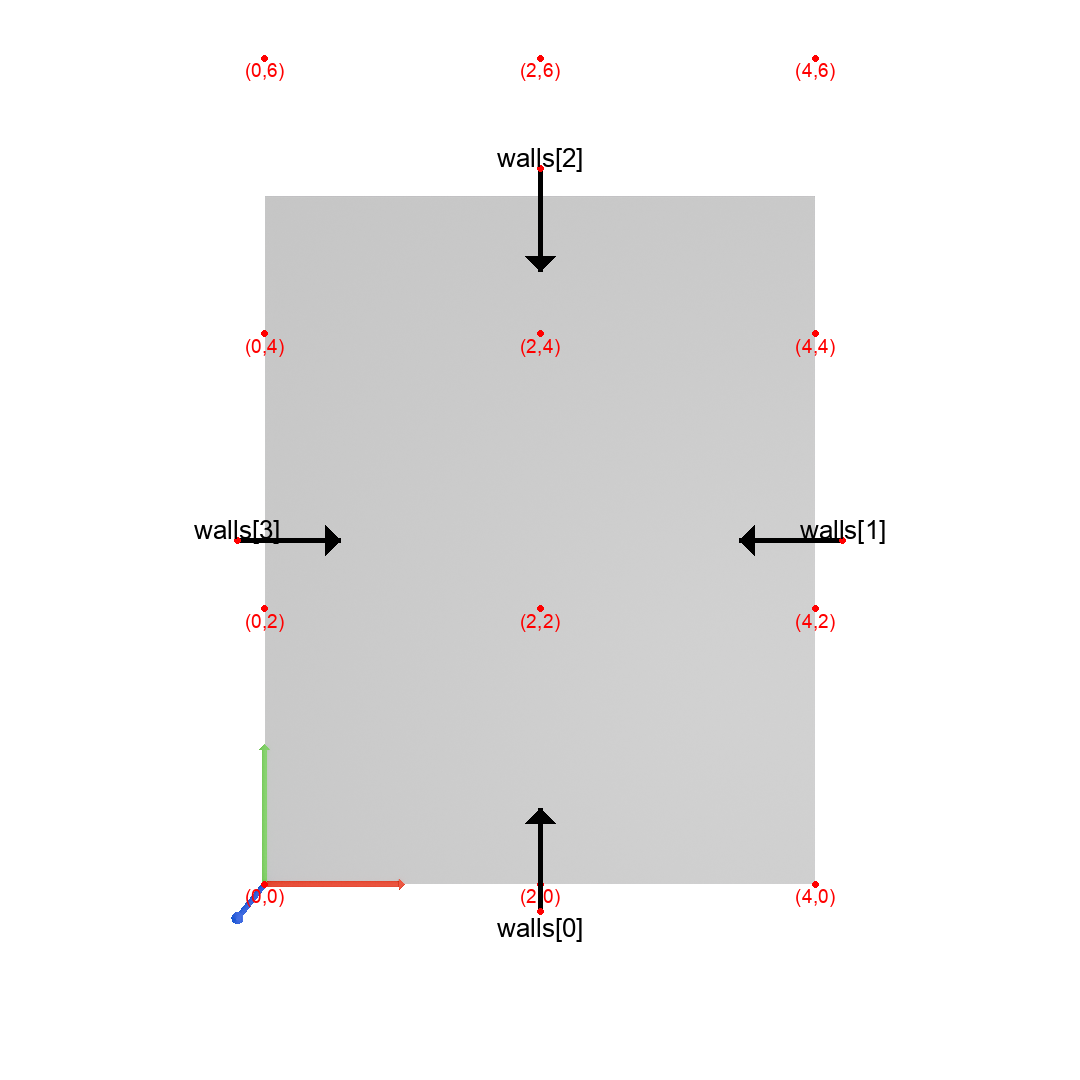


📷 side_rendering_45_3.png


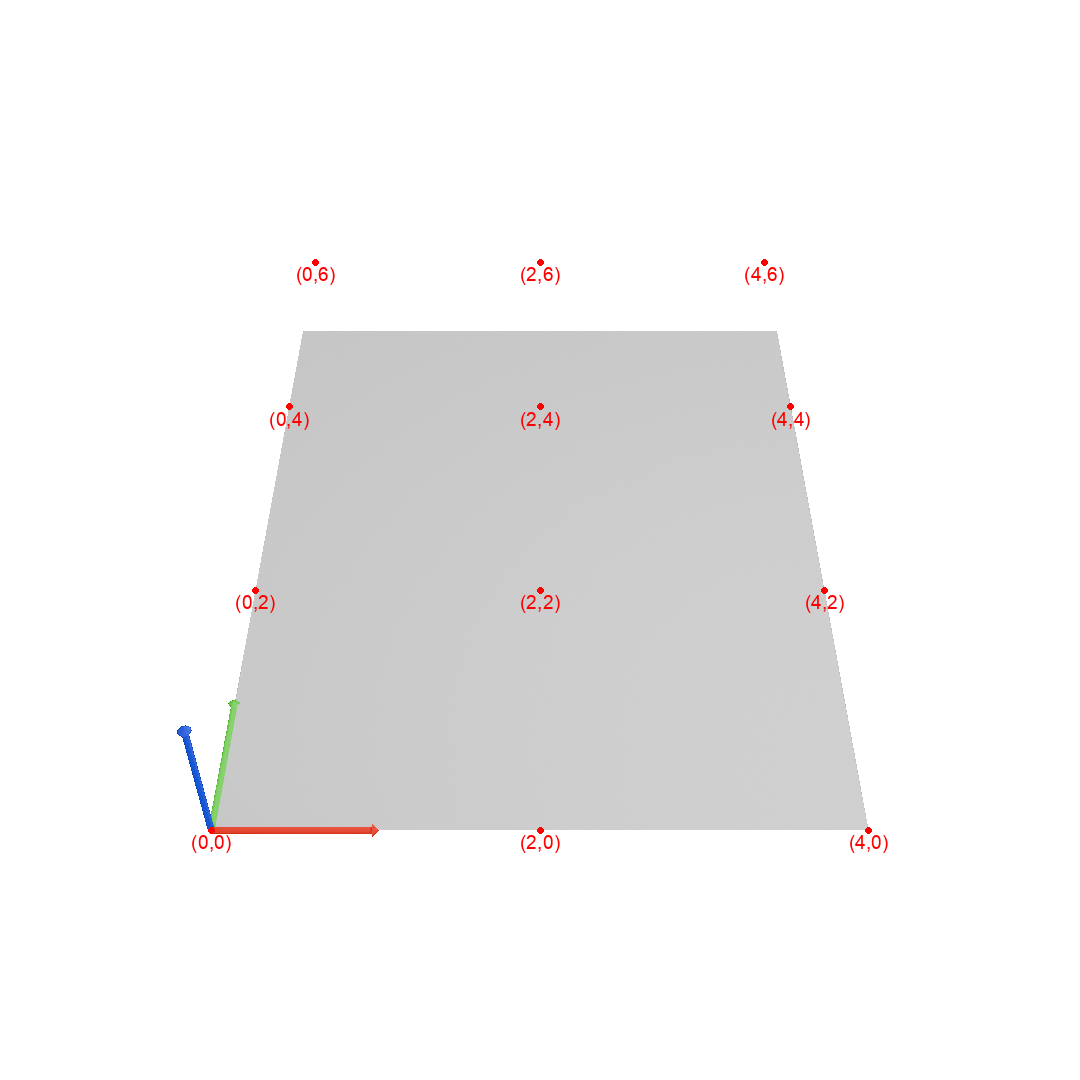


📷 frame_0000.png


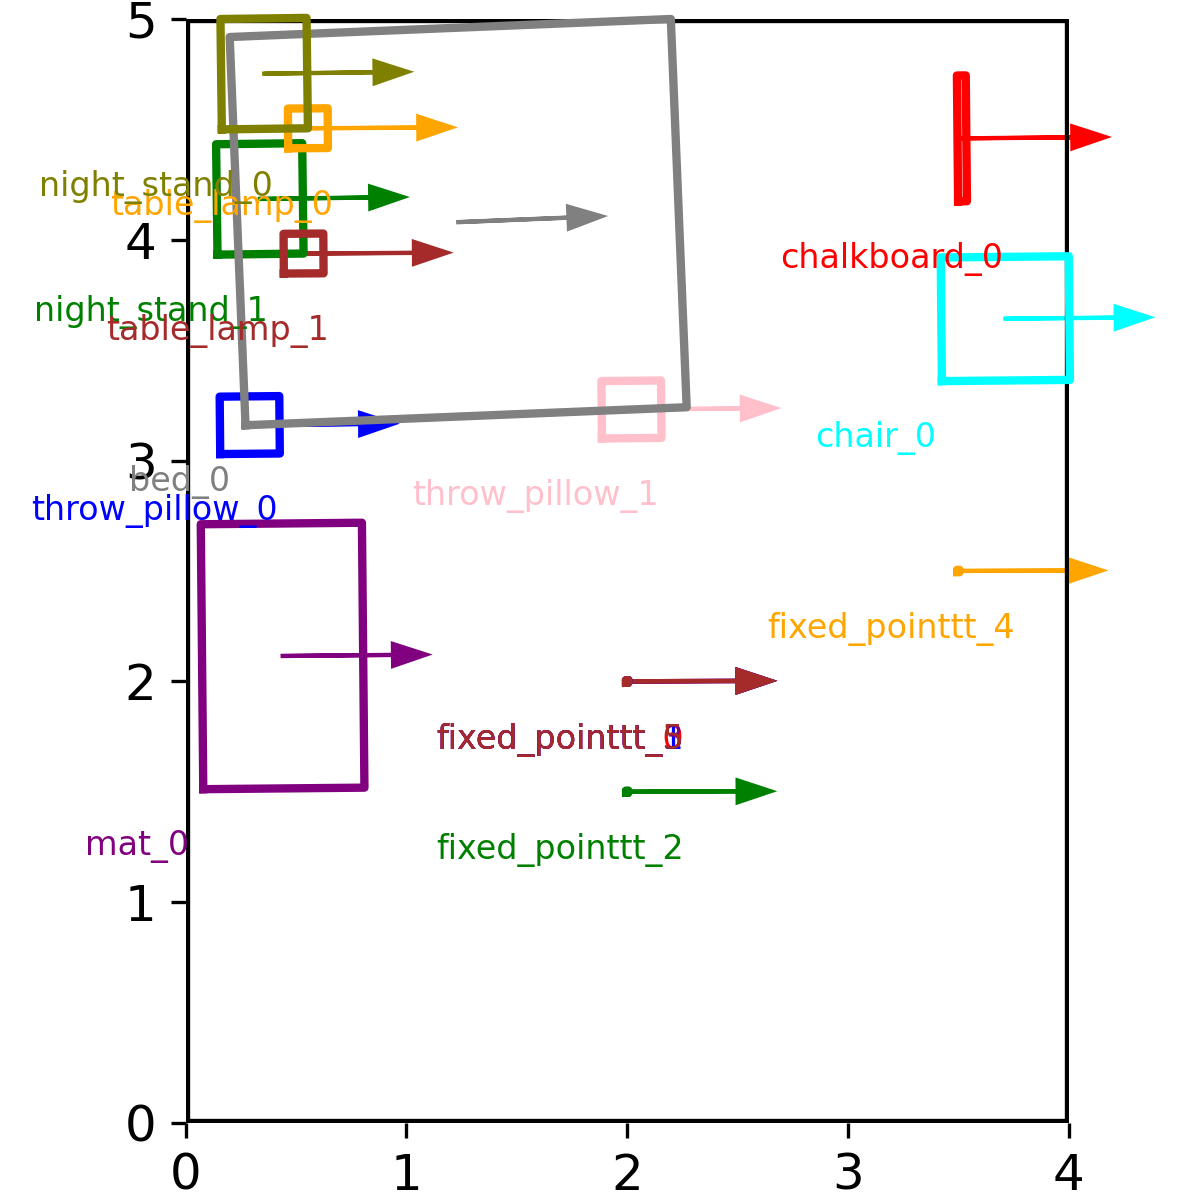


📷 frame_0010.png


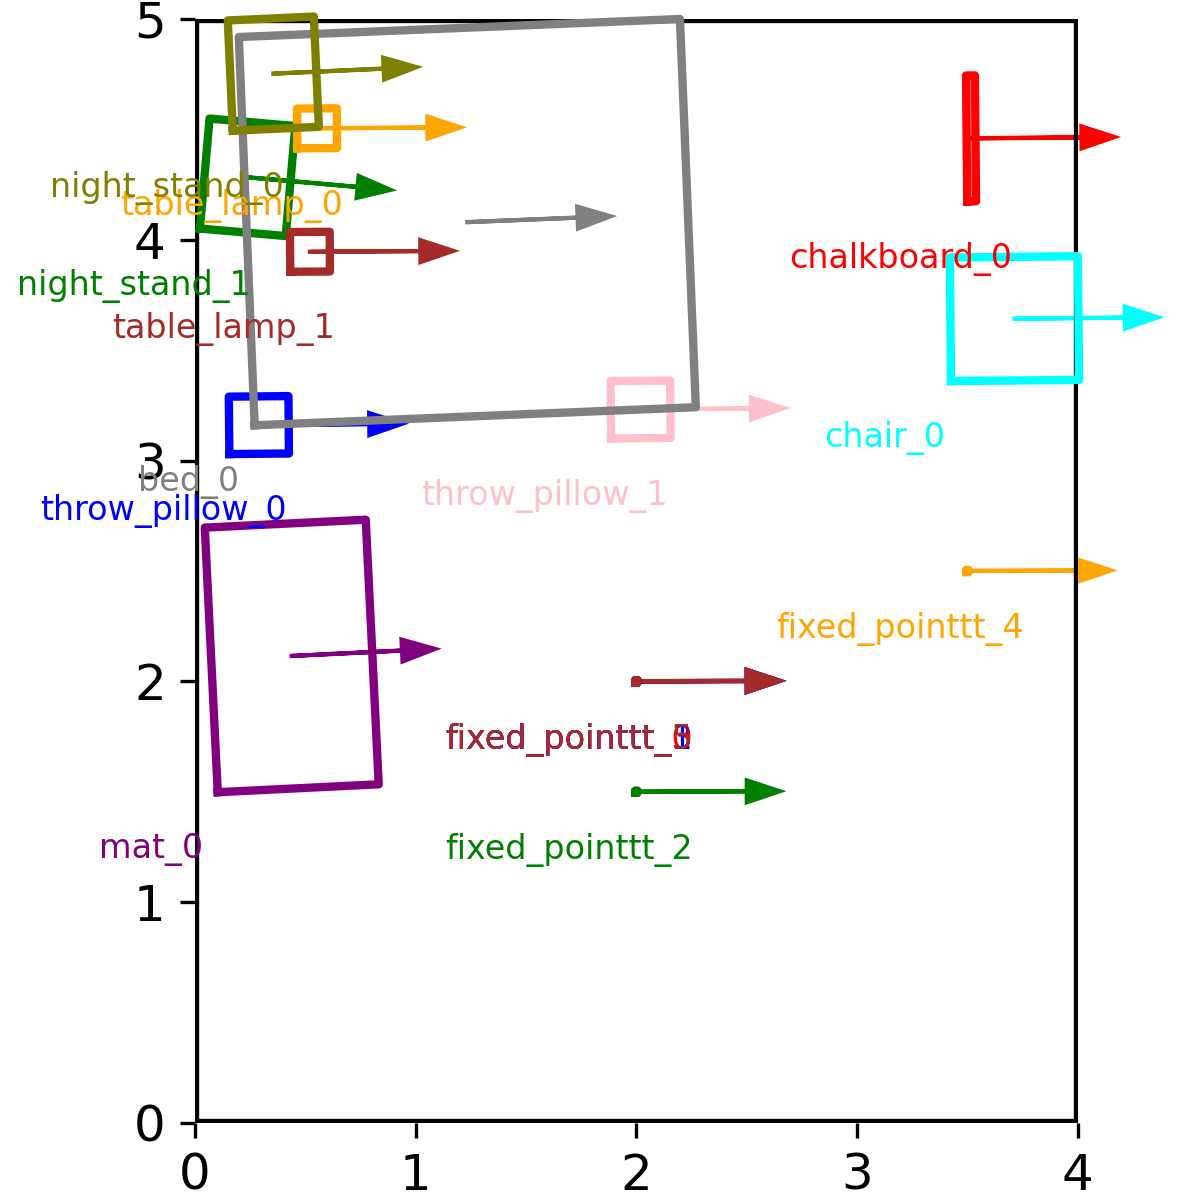


📷 frame_0020.png


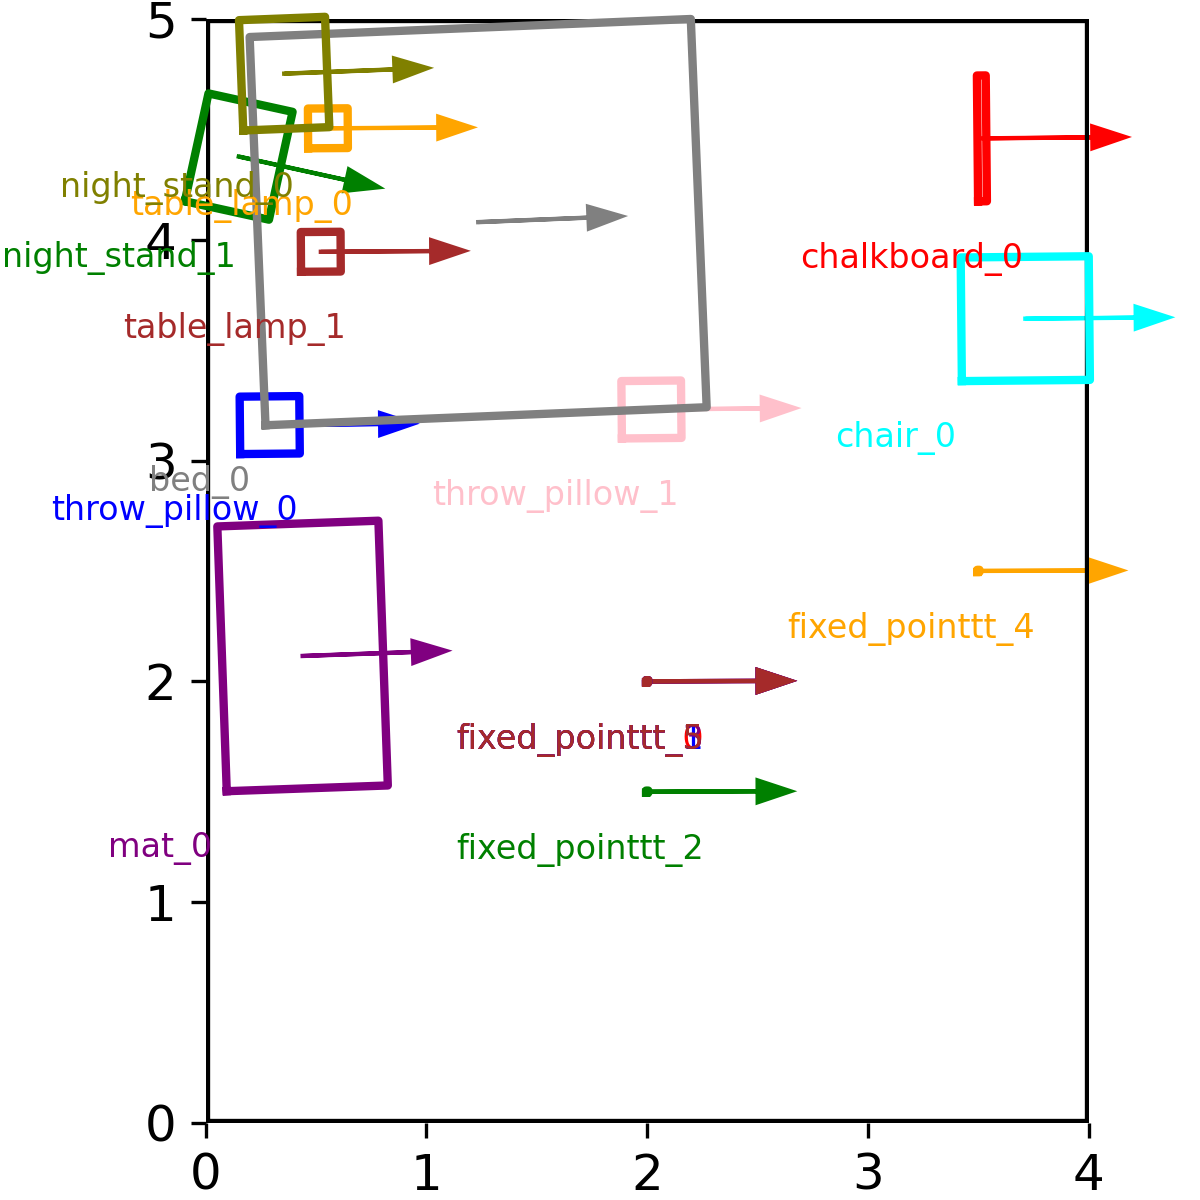



... 还有 40 张图片

✅ 结果查看完成

💾 所有结果已保存在: /content/drive/MyDrive/LayoutVLM_Project/results
   你可以在Google Drive中查看完整结果


In [20]:
import os
import json
from IPython.display import Image, display
import glob

result_dir = f'{PROJECT_DIR}/results'

print('='*60)
print('📊 查看生成结果')
print('='*60)

# 列出所有生成的文件
print('\n📁 生成的文件:')
!ls -lh {result_dir}

# 读取布局JSON
layout_file = f'{result_dir}/layout.json'

if os.path.exists(layout_file):
    print('\n' + '='*60)
    print('📋 布局数据 (layout.json):')
    print('='*60)

    with open(layout_file, 'r') as f:
        layout = json.load(f)

    # 显示简要信息
    print(f'\n✅ 成功生成 {len(layout)} 个物体的布局')

    # 显示前几个物体的信息
    print('\n前3个物体的信息:')
    for i, (obj_id, obj_info) in enumerate(list(layout.items())[:3], 1):
        print(f'\n{i}. {obj_id}:')
        print(f'   位置: {obj_info.get("position", "N/A")}')
        print(f'   旋转: {obj_info.get("rotation", "N/A")}')
        if len(layout) > 3 and i == 3:
            print(f'\n... 还有 {len(layout) - 3} 个物体')

    # 完整JSON预览
    print('\n完整JSON数据（前500字符）:')
    json_str = json.dumps(layout, indent=2)
    print(json_str[:500])
    if len(json_str) > 500:
        print(f'\n... (还有 {len(json_str) - 500} 字符)')

else:
    print('\n❌ 未找到 layout.json 文件')
    print('   请检查运行日志中的错误信息')

# 查找并显示渲染图片
print('\n' + '='*60)
print('🖼️  渲染图片:')
print('='*60)

image_files = glob.glob(f'{result_dir}/**/*.png', recursive=True)

if image_files:
    print(f'\n找到 {len(image_files)} 张图片:\n')
    for img_path in image_files[:5]:  # 最多显示5张
        print(f'📷 {os.path.basename(img_path)}')
        try:
            display(Image(filename=img_path, width=600))
            print()
        except:
            print(f'   ⚠️  无法显示图片')

    if len(image_files) > 5:
        print(f'\n... 还有 {len(image_files) - 5} 张图片')
else:
    print('\n⚠️  未找到渲染图片')
    print('   可能渲染功能未启用或发生错误')

print('\n' + '='*60)
print('✅ 结果查看完成')
print('='*60)
print(f'\n💾 所有结果已保存在: {result_dir}')
print('   你可以在Google Drive中查看完整结果')